# Models for Outcomes

In [1]:
import pandas as pd
import xarray as xr
import xgboost as xgb
import numpy as np
from pathlib import Path
import os
import json
from IPython.display import display, JSON

## Non-extreme outcomes

For modelling relationships between covariates and the average of the outcome variable among all ARs, we use the `xgboost` algorithm and assess variable importance via partial dependence plots at SHAP values.

### Round 1

In [2]:
with open('rounds/snow_round1_hyperparams.json', 'r') as f:
    json_data = json.load(f)

display(JSON(json_data))

<IPython.core.display.JSON object>

In [3]:
round1_snow = pd.read_csv('rounds/snow_xgb_round1.csv', index_col=False)

In [4]:
round1_snow

,Unnamed: 0,gamma,max_depth,reg_lambda,min_child_weight,eta,num_boost,val_rmse_mean,val_r2_mean,test-r2-mean-ols
0,0,0.01,3.0,0.01,500.0,0.300,160.0,0.339231,0.698089,0.832548
1,1,0.01,3.0,0.01,500.0,0.100,510.0,0.339322,0.697960,0.832548
2,2,0.01,3.0,0.01,500.0,0.050,956.0,0.339601,0.697452,0.832548
3,3,0.01,3.0,0.01,500.0,0.010,4205.0,0.339733,0.697217,0.832548
4,4,0.01,3.0,0.01,500.0,0.001,19999.0,0.345354,0.687192,0.832548
...,...,...,...,...,...,...,...,...,...,...
7555,7555,1.00,15.0,0.00,1000.0,0.300,0.0,0.616958,-0.001280,0.832548
7556,7556,1.00,15.0,0.00,1000.0,0.100,0.0,0.616958,-0.001280,0.832548
7557,7557,1.00,15.0,0.00,1000.0,0.050,0.0,0.616958,-0.001280,0.832548
7558,7558,1.00,15.0,0.00,1000.0,0.010,0.0,0.616958,-0.001280,0.832548


<Axes: xlabel='test_rmse', ylabel='Count'>

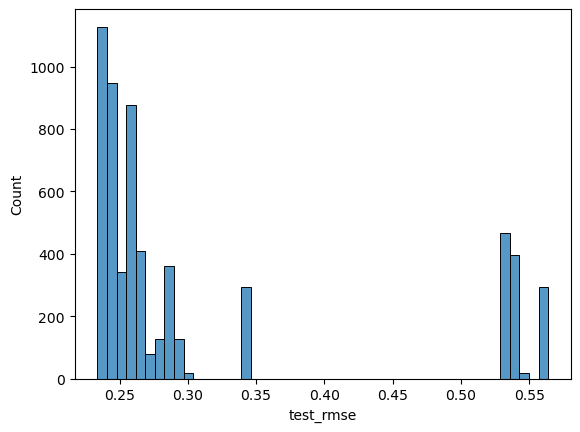

In [17]:
import seaborn as sns
sns.histplot(data=round1_snow, x='test_rmse')

In [44]:
best_performers = round1_snow.loc[round1_snow.test_rmse.idxmin()]
best_performers

Unnamed: 0           881.000000
gamma                  0.010000
max_depth              3.000000
reg_lambda             1.000000
min_child_weight       0.000001
eta                    0.010000
num_boost           1698.000000
test_rmse              0.233754
Name: 881, dtype: float64

In [41]:
best_performers.max_depth

210     3.0
211     3.0
212     3.0
215     3.0
216     3.0
       ... 
4737    5.0
4741    5.0
4742    5.0
4746    5.0
4747    5.0
Name: max_depth, Length: 1080, dtype: float64

In [27]:
import pandas as pd
import xarray as xr
import xgboost as xgb
import numpy as np
from itertools import product
from pathlib import Path
import os

import multiprocessing

load_path = Path(os.getcwd()).parents[0]/Path('dataset/datasets/model_ready/train.csv')
train_data = pd.read_csv(load_path, index_col='Label')

X = train_data[['max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 'max_landfalling_omega500', 'max_IWV_ais', 'cumulative_landfalling_area', 'max_south_extent']]
snow_var = 'cumulative_snowfall_ais'
temp_var = 'max_2m_temp_ais'


# some basic cross validation
# for snowfall
etas = np.array([0.001, 0.01, 0.05, 0.1, 0.2, 0.3])
# units of Y are in gigatons, a loss of 1 will be really
# high, so that seems like a reasonable upper bound
gammas = np.array([0.0005, 0.001, 0.005, 0.01, 0.05])
# intuition tells me we won't need to go THAT deep
max_depth = np.array([3, 7, 10, 15, 30])
# don't have a great intuition on this, mostly testing
lambdas = np.array([0, 0.3, 0.7, 1, 5])
# same
min_child_weights = np.array([0.0005, 0.001, 0.005, 0.01, 0.05])
# since we're doing early stopping, this should be good
nrounds = 500
early_stopping_rounds = 10
tree_method = 'exact'
booster = 'gbtree'

hyperparams_lst = list(product(gammas, max_depth, lambdas, min_child_weights))

# function that will be run in parallel on chunks on the hyperparameters
def process_hyperparam_chunk(lst):

    train_data = pd.read_csv(load_path, index_col='Label')
    X = train_data[['max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 'max_landfalling_omega500', 'max_IWV_ais', 'cumulative_landfalling_area', 'max_south_extent']]

    num_eta = len(etas)
    results_lst = np.zeros((len(etas)*len(lst), len(lst[0]) + 3))
    
    for i, param_set in enumerate(lst):
        for j, eta in enumerate(etas):
            params = dict(booster='gbtree',
                   eta=eta,
                   gamma=param_set[0],
                   max_depth=param_set[1],
                   reg_lambda=param_set[2],
                   min_child_weight=param_set[3],
                   tree_method=tree_method)
            dtrain = xgb.DMatrix(X, label=train_data[snow_var])
            res = xgb.cv(params,
                   dtrain,
                   nrounds,
                   nfold=5,
                   seed=12345,
                   early_stopping_rounds=early_stopping_rounds)
            results_lst[i*num_eta + j,:] = np.array(list(param_set) + [eta] + [res.shape[0]] + [float(res['test-rmse-mean'].iloc[-1])])

            results_df = pd.DataFrame(results_lst, columns=['gamma', 'max_depth', 'reg_lambda', 'min_child_weight', 'eta', 'num_boost', 'test_rmse'])

    return results_df

# creating the chunks of hyperparameters
chunk_lst = []
chunk_size = 10


for i in range(0, len(hyperparams_lst), chunk_size):
    chunk_lst.append(hyperparams_lst[i:i + chunk_size])

In [45]:
params = dict(booster='gbtree',
                   eta=0.5,
                   gamma=0.5,
                   max_depth=3,
                   reg_lambda=3,
                   min_child_weight=0.01,
                   tree_method='exact')

In [46]:
x_cols = ['max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 'avg_landfalling_minomega', 'max_IWV_ais', 'cumulative_landfalling_area', 'max_south_extent']
y_col = 'cumulative_snowfall_ais'
train_data = pd.read_csv(load_path, index_col='Label')
X = train_data[x_cols]
y = train_data[y_col]

In [101]:
dtrain = xgb.DMatrix(X, label=train_data[snow_var])

In [99]:
early_stopping_callback = xgb.callback.EarlyStopping(
            rounds=100,
            metric_name='r2',
            maximize=True)

res = xgb.cv(params,
                dtrain,
                nrounds,
                nfold=5,
                seed=12345,
                custom_metric=predictive_r2,
                callbacks=[early_stopping_callback])

In [100]:
res

,train-rmse-mean,train-rmse-std,test-rmse-mean,test-rmse-std,train-r2-mean,train-r2-std,test-r2-mean,test-r2-std
0,0.397463,0.008766,0.404353,0.039786,0.586636,0.004280,0.571050,0.026162
1,0.296113,0.008881,0.310921,0.038634,0.770593,0.006193,0.746595,0.028808
2,0.249101,0.009185,0.271494,0.036824,0.837664,0.006342,0.806870,0.025620
3,0.225085,0.007588,0.254315,0.034496,0.867444,0.004727,0.830435,0.023173
4,0.211878,0.006919,0.248090,0.033410,0.882544,0.003923,0.838614,0.021919
5,0.202905,0.006590,0.243590,0.034862,0.892283,0.003522,0.844310,0.024266
6,0.197010,0.005304,0.241860,0.034706,0.898442,0.002442,0.846448,0.024450
7,0.192574,0.004526,0.241745,0.034333,0.902958,0.001789,0.846552,0.024226
8,0.188921,0.004186,0.239066,0.031519,0.906604,0.001482,0.849892,0.021356
9,0.186967,0.003200,0.237963,0.032467,0.908508,0.001405,0.851235,0.022628


In [63]:
def predictive_r2(y_pred, y_true_dmat):
    y_true = y_true_dmat.get_label()
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    # Handle the case where ss_tot is zero (e.g., constant y_true)
    if ss_tot == 0:
        r2 = 1.0 if ss_res == 0 else 0.0
    else:
        r2 = 1 - (ss_res / ss_tot)

    return 'r2', r2

In [102]:
dtrain.get_label()

array([0.04794091, 0.62176436, 0.03141662, ..., 0.3192777 , 0.1394995 ,
       0.05259206], dtype=float32)